In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df= pd.read_csv(r'..\data\processed\df_preprocessed.csv')
#df = df.drop(columns=['profit','profit_per_unit', 'sales_per_unit' ])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   row_id           9994 non-null   int64  
 1   order_id         9994 non-null   str    
 2   order_date       9994 non-null   str    
 3   ship_date        9994 non-null   str    
 4   ship_mode        9994 non-null   str    
 5   customer_id      9994 non-null   str    
 6   segment          9994 non-null   str    
 7   city             9994 non-null   str    
 8   state            9994 non-null   str    
 9   postal_code      9994 non-null   int64  
 10  region           9994 non-null   str    
 11  product_id       9994 non-null   str    
 12  category         9994 non-null   str    
 13  sub-category     9994 non-null   str    
 14  product_name     9994 non-null   str    
 15  sales            9994 non-null   float64
 16  quantity         9994 non-null   int64  
 17  discount         9994 non

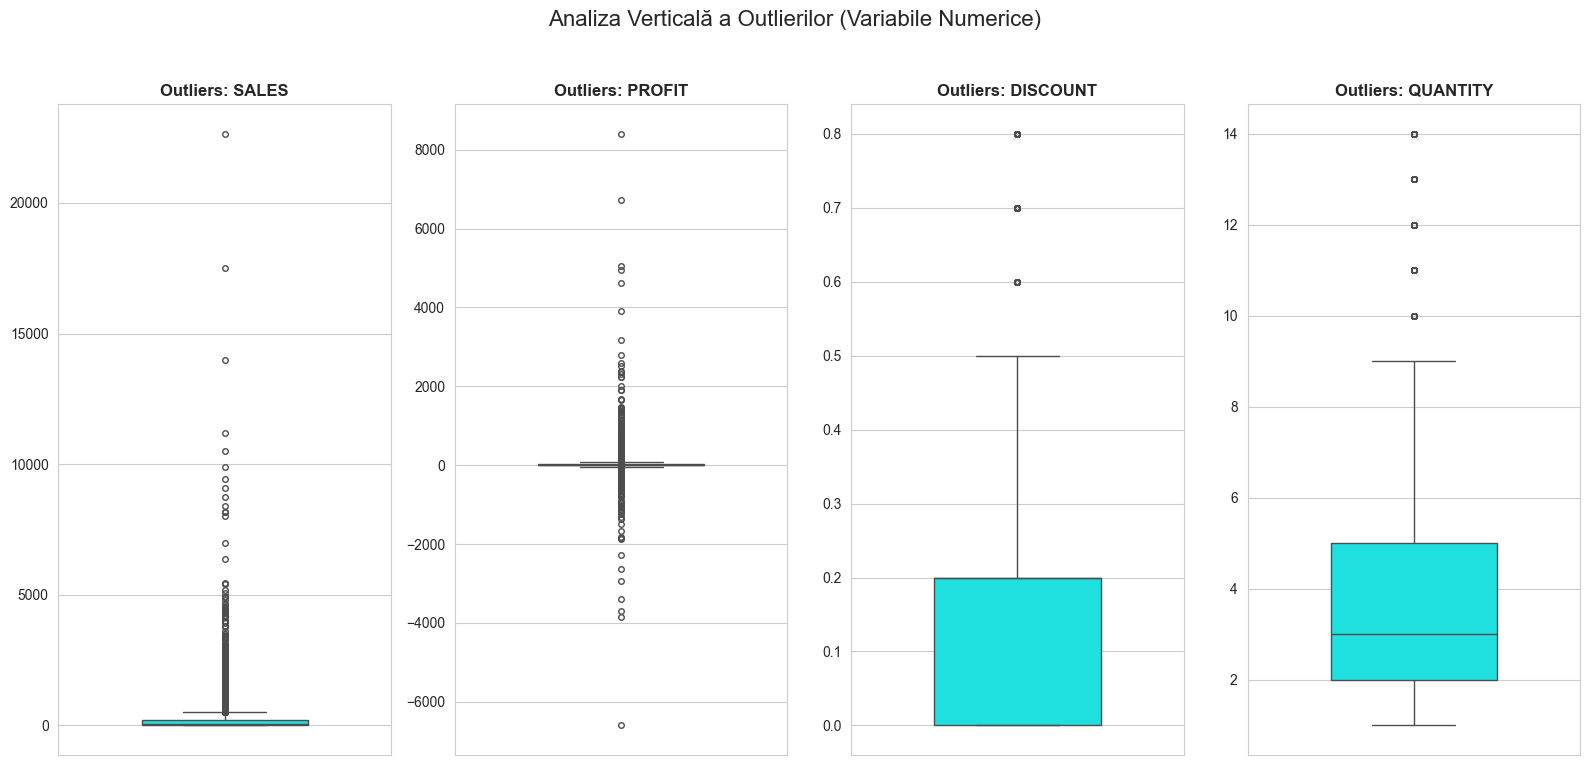


========================== IDENTIFICARE DETALIATĂ A TRANZACȚIILOR EXTREME ==========================

>>> Outlieri detectați pentru coloana: SALES
Praguri: [-271.71, 498.93] | Total detectați: 1167
customer_id      product_id                                              product_name       order_id order_date     sales
   SM-20320 TEC-MA-10002412     Cisco TelePresence System EX90 Videoconferencing Unit CA-2014-145317 2014-03-18 22638.480
   TC-20980 TEC-CO-10004722                     Canon imageCLASS 2200 Advanced Copier CA-2016-118689 2016-10-02 17499.950
   RB-19360 TEC-CO-10004722                     Canon imageCLASS 2200 Advanced Copier CA-2017-140151 2017-03-23 13999.960
   TA-21385 TEC-CO-10004722                     Canon imageCLASS 2200 Advanced Copier CA-2017-127180 2017-10-22 11199.968
   HL-15040 TEC-CO-10004722                     Canon imageCLASS 2200 Advanced Copier CA-2017-166709 2017-11-17 10499.970
   AB-10105 OFF-BI-10000545          GBC Ibimaster 500 Manual ProClic

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 20)


num_cols = ['sales', 'profit', 'discount', 'quantity']
context_cols = ['customer_id', 'product_id', 'product_name', 'order_id', 'order_date']

# 2. Crearea graficelor (Boxplot-uri verticale aliniate)
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 8))
sns.set_style("whitegrid")

for i, col in enumerate(num_cols):
    # Desenăm boxplot vertical
    sns.boxplot(y=df[col], ax=axes[i], color='cyan', width=0.5, fliersize=4)
    axes[i].set_title(f'Outliers: {col.upper()}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Eliminăm label-ul axei Y pentru curățenie vizuală

plt.suptitle('Analiza Verticală a Outlierilor (Variabile Numerice)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



# 3. Identificarea și Afișarea în Terminal
print(f"\n{' IDENTIFICARE DETALIATĂ A TRANZACȚIILOR EXTREME ':=^100}")

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_lim = Q1 - 1.5 * IQR
    upper_lim = Q3 + 1.5 * IQR


    current_outliers = df[(df[col] < lower_lim) | (df[col] > upper_lim)].copy()

    print(f"\n>>> Outlieri detectați pentru coloana: {col.upper()}")
    print(f"Praguri: [{lower_lim:.2f}, {upper_lim:.2f}] | Total detectați: {len(current_outliers)}")

    if not current_outliers.empty:

        sort_col = col
        display_df = current_outliers[context_cols + [col]].sort_values(by=sort_col, ascending=False).head(10)
        print(display_df.to_string(index=False))
    else:
        print("Nu exista outlieri.")
    print("-" * 100)


print(f"\n{' ANOMALII CATEGORICE (VALORI CU FRECVENTA RARA < 1%) ':=^100}")
categorical_cols = ['category', 'sub-category', 'state', 'city', 'region', 'segment', 'ship_mode']

for col in categorical_cols:
    counts = df[col].value_counts(normalize=True)
    rare_values = counts[counts < 0.01] # Valori care apar în mai puțin de 1% din date
    if not rare_values.empty:
        print(f"Coloana {col:12} | {len(rare_values)} valori rare detectate (ex: {rare_values.index[0]})")

In [6]:
def get_outlier_indices(df, columns):
    all_outlier_indices = set()

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        all_outlier_indices.update(outliers)
        print(f"Coloana {col:10} | Detectati: {len(outliers)} outlieri")

    return list(all_outlier_indices)

cols_to_check = ['discount', 'quantity']
outlier_idx = get_outlier_indices(df, cols_to_check)

df_removed_outliers = df.loc[outlier_idx].copy()
df_cleaned = df.drop(index=outlier_idx)

df_removed_outliers.to_csv('outliers_removed.csv', index=False)
df_cleaned.to_csv('df_cleaned_no_outliers.csv', index=False)

print("-" * 50)
print(f"Salvat 'outliers_removed.csv' ({len(df_removed_outliers)} randuri)")
print(f"Salvat 'df_cleaned_no_outliers.csv' ({len(df_cleaned)} randuri)")
print("-" * 50)

Coloana discount   | Detectati: 856 outlieri
Coloana quantity   | Detectati: 170 outlieri
--------------------------------------------------
Salvat 'outliers_removed.csv' (1014 randuri)
Salvat 'df_cleaned_no_outliers.csv' (8980 randuri)
--------------------------------------------------


In [9]:
import pandas as pd

cols_to_check = ['discount', 'quantity', 'profit', 'sales']
all_indices = []

for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    all_indices.extend(df[(df[col] < lower) | (df[col] > upper)].index)

outlier_idx = list(set(all_indices))
df_outliers = df.loc[outlier_idx]
total_outliers_count = len(df_outliers)

top_outlier_clients = df_outliers['customer_id'].value_counts().head(10)

summary_data = []
for cid, count in top_outlier_clients.items():
    total_client_rows = len(df[df['customer_id'] == cid])
    perc_in_client_history = (count / total_client_rows) * 100
    perc_in_total_outliers = (count / total_outliers_count) * 100

    summary_data.append([
        cid,
        total_client_rows,
        count,
        f"{perc_in_client_history:.1f}%",
        f"{perc_in_total_outliers:.1f}%"
    ])

df_res = pd.DataFrame(summary_data, columns=[
    'Customer ID',
    'Total Randuri',
    'Nr Outliers',
    '% din Istoric Client',
    '% din Total Outliers'
])

print(f"\n{' ANALIZA PONDERII OUTLIERILOR PER CUSTOMER ':=^75}")
print(df_res.to_string(index=False))
print("-" * 75)
print(f"Total randuri outlier in dataset: {total_outliers_count}")
print("=" * 75)


================ ANALIZA PONDERII OUTLIERILOR PER CUSTOMER ================
Customer ID  Total Randuri  Nr Outliers % din Istoric Client % din Total Outliers
   JE-15715             22           13                59.1%                 0.5%
   KL-16645             29           12                41.4%                 0.4%
   ZC-21910             31           12                38.7%                 0.4%
   BH-11710             24           11                45.8%                 0.4%
   EA-14035             25           11                44.0%                 0.4%
   SV-20365             32           11                34.4%                 0.4%
   LA-16780             26           11                42.3%                 0.4%
   BM-11650             29           11                37.9%                 0.4%
   JK-15730             20           11                55.0%                 0.4%
   LB-16795             24           10                41.7%                 0.4%
---------------------